# 4. Re-building model_v1 based on previous observations from confusion matrix and efficiency vs jet features: #


1. From ROC Curves - Quark has lowest AUC and W/Z confusion - suggest model isn't capturing fine-grained spatial structure well enough
     - Smaller kernel size (2x2) in early layers - captures finer pixel-level detail
     - More filters - increase from 32/64/128 to 64/128/256 - gives network more capacity to learn subtle differences

2. From Efficiency Plots - W and Z collapse at high transverse momentum where jets become boosted and substructures merge.
    - A fourth Conv2D block - deeper networks to handle multi-scale structure of boosted jets better
    - BatchNorm - $p_{T}$ plot shows high variance at extreme values - BatchNorm stabilises by normalising activations across the batch
     

*Note: upon running the model, based on the first few epochs, it was clear the model_v2 was overfitting the data with a much worse validation accuracy despite having a slightly better training accuracy. Thus, testing this model as an improvement would prove completely unfruitful.*

#EXTENSION TASK: #

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

# List everything in the top level of your Drive
for item in sorted(os.listdir('/content/drive/MyDrive/Physics 3rd Yr/PHAS0056: Machine Learning/Final Proj/')):
    print(item)

main_dir = '/content/drive/MyDrive/Physics 3rd Yr/PHAS0056: Machine Learning/Final Proj/' #main directory on Google Drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Notebooks
Reference Papers1. .gdoc
Results
data_files
datasets
lhcJets.ipynb


In [2]:
import h5py
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sklearn.utils import shuffle
print(os.getcwd())

/content


In [3]:
import tensorflow as tf
print(tf)
print(getattr(tf, "__file__", "no file location"))

<module 'tensorflow' from '/usr/local/lib/python3.12/dist-packages/tensorflow/__init__.py'>
/usr/local/lib/python3.12/dist-packages/tensorflow/__init__.py


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import math

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

import matplotlib.style
import matplotlib as mpl
from scipy import linalg


#Set default figure size
#mpl.rcParams['figure.figsize'] = [12.0, 8.0] #Inches... of course it is inches
mpl.rcParams["legend.frameon"] = False
mpl.rcParams['figure.dpi']=200 # dots per inch

#Useful for debugging problems
print(tf.__version__)
print(np.__version__)

2.19.0
2.0.2


In [5]:
print("GPUs:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA:", tf.test.is_built_with_cuda())

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True


In [6]:
def build_jet_cnn_v1(input_shape = (100,100, 1) , n_classes = 5):
    '''

    General model for an image classification model
    - Look at week 4 - REDO USING A CONVOLUTION NEURAL NETWORK

    Input:

    Input_shape =
    input_x = x dimension of input image matrix
    input_y = y dimensino of input image matrix
    channels =
             1=> if we are only looking at Full image
             3=> if we are look at Full Image, ECAL and HCAL
    n_classes = no. of output nodes

    Ouput:
    Returns model using a softmax activation function at the output nodes for
    image classification

    '''

    l2_reg = keras.regularizers.l2(1e-4)

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=input_shape))

    model.add(keras.layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=l2_reg))
    model.add(keras.layers.LeakyReLU(alpha=0.1))
    model.add(keras.layers.MaxPooling2D((2,2)))

    model.add(keras.layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=l2_reg))
    model.add(keras.layers.LeakyReLU(alpha=0.1))
    model.add(keras.layers.MaxPooling2D((2,2)))

    model.add(keras.layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=l2_reg))
    model.add(keras.layers.LeakyReLU(alpha=0.1))
    model.add(keras.layers.MaxPooling2D((2,2)))

    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(256, kernel_regularizer=l2_reg))
    model.add(keras.layers.LeakyReLU(alpha=0.1))
    model.add(keras.layers.Dropout(0.3))
    model.add(keras.layers.Dense(n_classes))

    model.summary()

    model.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    return model


In [7]:
#model_v2 = build_jet_cnn_v2()

In [8]:
## Making model_v2 directory ##

#model_v2_dir = main_dir + '/Results/Model_v2'

In [9]:
#Loading dataset

## Loading data ##

#val_images = np.load(main_dir + "/datasets/validation_images.npy")
#val_labels = np.load(main_dir + "/datasets/validation_labels.npy")

#Train + Test Dataset
#data_images = np.load(main_dir +"/datasets/train_images.npy")
#data_labels = np.load(main_dir +"/datasets/train_labels.npy")


#Adjusting shape of image arrays to be compatible with model input

#val_images = val_images[...,np.newaxis]
#data_images = data_images[...,np.newaxis]

#shuffling data #

#val_images, val_labels = shuffle(val_images, val_labels, random_state = 42)
#data_images, data_labels = shuffle(data_images, data_labels, random_state=42)

#Making Train and Test Dataset

#split = int(0.8*len(data_images))

#Train dataset

#train_images = data_images[:split]
#train_labels = data_labels[:split]

#Test dataset

#test_images = data_images[split:]
#test_labels = data_labels[split:]

#train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

In [10]:
#early_stop_v2 = keras.callbacks.EarlyStopping(
#    monitor='val_loss', patience=10, restore_best_weights=True
#)

#history_v2 = model_v2.fit(
#    train_images, train_labels,
#    validation_data=(val_images, val_labels),
#    epochs=200,
#    batch_size=64,
#    callbacks=[early_stop_v2]
#)

#model_v2.save(model_v2_dir + '/jet_cnn_v2.keras')

# 5. Loading and Setting Features Dataset: #

In [11]:
#Loading features dataset#

val_features = pd.read_parquet(main_dir + '/datasets/val_p4_features.parquet')
val_labels = np.load(main_dir + '/datasets/val_p4_labels.npy')

data_features = pd.read_parquet(main_dir + '/datasets/data_p4_features.parquet')
data_labels = np.load(main_dir + '/datasets/data_p4_labels.npy')

val_features.shape, val_labels.shape, data_features.shape, data_labels.shape

((30000, 59), (30000,), (80000, 59), (80000,))

In [12]:
#Removing labels

# Columns to exclude — these are labels not features
exclude = ['j_g', 'j_q', 'j_w', 'j_z', 'j_t', 'j_undef']

feature_cols = [c for c in data_features.columns if c not in exclude]
print(f"Using {len(feature_cols)} input features:")
print(feature_cols)

Using 53 input features:
['j_ptfrac', 'j_pt', 'j_eta', 'j_mass', 'j_tau1_b1', 'j_tau2_b1', 'j_tau3_b1', 'j_tau1_b2', 'j_tau2_b2', 'j_tau3_b2', 'j_tau32_b1', 'j_tau32_b2', 'j_zlogz', 'j_c1_b0', 'j_c1_b1', 'j_c1_b2', 'j_c2_b1', 'j_c2_b2', 'j_d2_b1', 'j_d2_b2', 'j_d2_a1_b1', 'j_d2_a1_b2', 'j_m2_b1', 'j_m2_b2', 'j_n2_b1', 'j_n2_b2', 'j_tau1_b1_mmdt', 'j_tau2_b1_mmdt', 'j_tau3_b1_mmdt', 'j_tau1_b2_mmdt', 'j_tau2_b2_mmdt', 'j_tau3_b2_mmdt', 'j_tau32_b1_mmdt', 'j_tau32_b2_mmdt', 'j_c1_b0_mmdt', 'j_c1_b1_mmdt', 'j_c1_b2_mmdt', 'j_c2_b1_mmdt', 'j_c2_b2_mmdt', 'j_d2_b1_mmdt', 'j_d2_b2_mmdt', 'j_d2_a1_b1_mmdt', 'j_d2_a1_b2_mmdt', 'j_m2_b1_mmdt', 'j_m2_b2_mmdt', 'j_n2_b1_mmdt', 'j_n2_b2_mmdt', 'j_mass_trim', 'j_mass_mmdt', 'j_mass_prun', 'j_mass_sdb2', 'j_mass_sdm1', 'j_multiplicity']


In [13]:
from sklearn.preprocessing import StandardScaler

# Preparing data #

#Data and validation features
X_data = data_features[feature_cols].to_numpy().astype(np.float32)
X_val = val_features[feature_cols].to_numpy().astype(np.float32)

#Data and validation labels
y_data = data_labels.copy()
y_val = val_labels.copy()

# Replace any NaN or Inf values — some substructure variables are undefined

X_data = np.nan_to_num(X_data, nan=0.0, posinf=0.0, neginf=0.0)
X_val   = np.nan_to_num(X_val,   nan=0.0, posinf=0.0, neginf=0.0)

# Fit scaler on train only, apply same transform to val
scaler  = StandardScaler()
X_data = scaler.fit_transform(X_data)
X_val   = scaler.transform(X_val)

# Shuffle
X_data, y_data = shuffle(X_data, y_data, random_state=42)
X_val,   y_val   = shuffle(X_val,   y_val,   random_state=42)

In [14]:
#Splitting data into training and test sets

split = int(0.8*len(X_data))

train_data = X_data[:split]
train_labels = y_data[:split]

test_data = X_data[split:]
test_labels = y_data[split:]

train_data.shape, train_labels.shape, test_data.shape, test_labels.shape



((64000, 53), (64000,), (16000, 53), (16000,))

In [15]:
def build_features_dnn(n_features, n_classes=5):
    '''
    Dense neural network trained on jet substructure features only.
    No image input — uses the 47 scalar physics observables.

    Architecture mirrors the complexity of model_v1 for a fair comparison:
    same number of Dense layers, same regularisation strategy.
    '''
    l2_reg = keras.regularizers.l2(1e-4)

    model = keras.Sequential([
        keras.layers.Input(shape=(n_features,)),

        # Layer 1
        keras.layers.Dense(256, kernel_regularizer=l2_reg),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(alpha=0.1),
        keras.layers.Dropout(0.3),

        # Layer 2
        keras.layers.Dense(256, kernel_regularizer=l2_reg),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(alpha=0.1),
        keras.layers.Dropout(0.3),

        # Layer 3
        keras.layers.Dense(128, kernel_regularizer=l2_reg),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(alpha=0.1),
        keras.layers.Dropout(0.3),

        # Output
        keras.layers.Dense(n_classes)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=0.0),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    model.summary()
    return model


In [16]:
model_features = build_features_dnn(n_features=X_data.shape[1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,717 (452.02 KB)

 Trainable params: 114,437 (447.02 KB)

 Non-trainable params: 1,280 (5.00 KB)

In [17]:
#Training model#

early_stop_feat = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_features = model_features.fit(
    train_data, train_labels,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop_feat]
)

# Save immediately after training
model_features.save(main_dir + '/Results/Model_features/jet_features_dnn.keras')

Epoch 1/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7121 - loss: 0.8546 - val_accuracy: 0.7994 - val_loss: 0.6475
Epoch 2/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7688 - loss: 0.7242 - val_accuracy: 0.8075 - val_loss: 0.6182
Epoch 3/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7805 - loss: 0.6914 - val_accuracy: 0.8067 - val_loss: 0.6055
Epoch 4/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7836 - loss: 0.6795 - val_accuracy: 0.8061 - val_loss: 0.6119
Epoch 5/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7884 - loss: 0.6642 - val_accuracy: 0.8092 - val_loss: 0.5926
Epoch 6/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7876 - loss: 0.6613 - val_accuracy: 0.8102 - val_loss: 0.5940
Epoch 7/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7910 - loss: 0.6535 - val_accuracy: 0.8092 - val_loss: 0.5928
Epoch 8/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7903 - loss: 

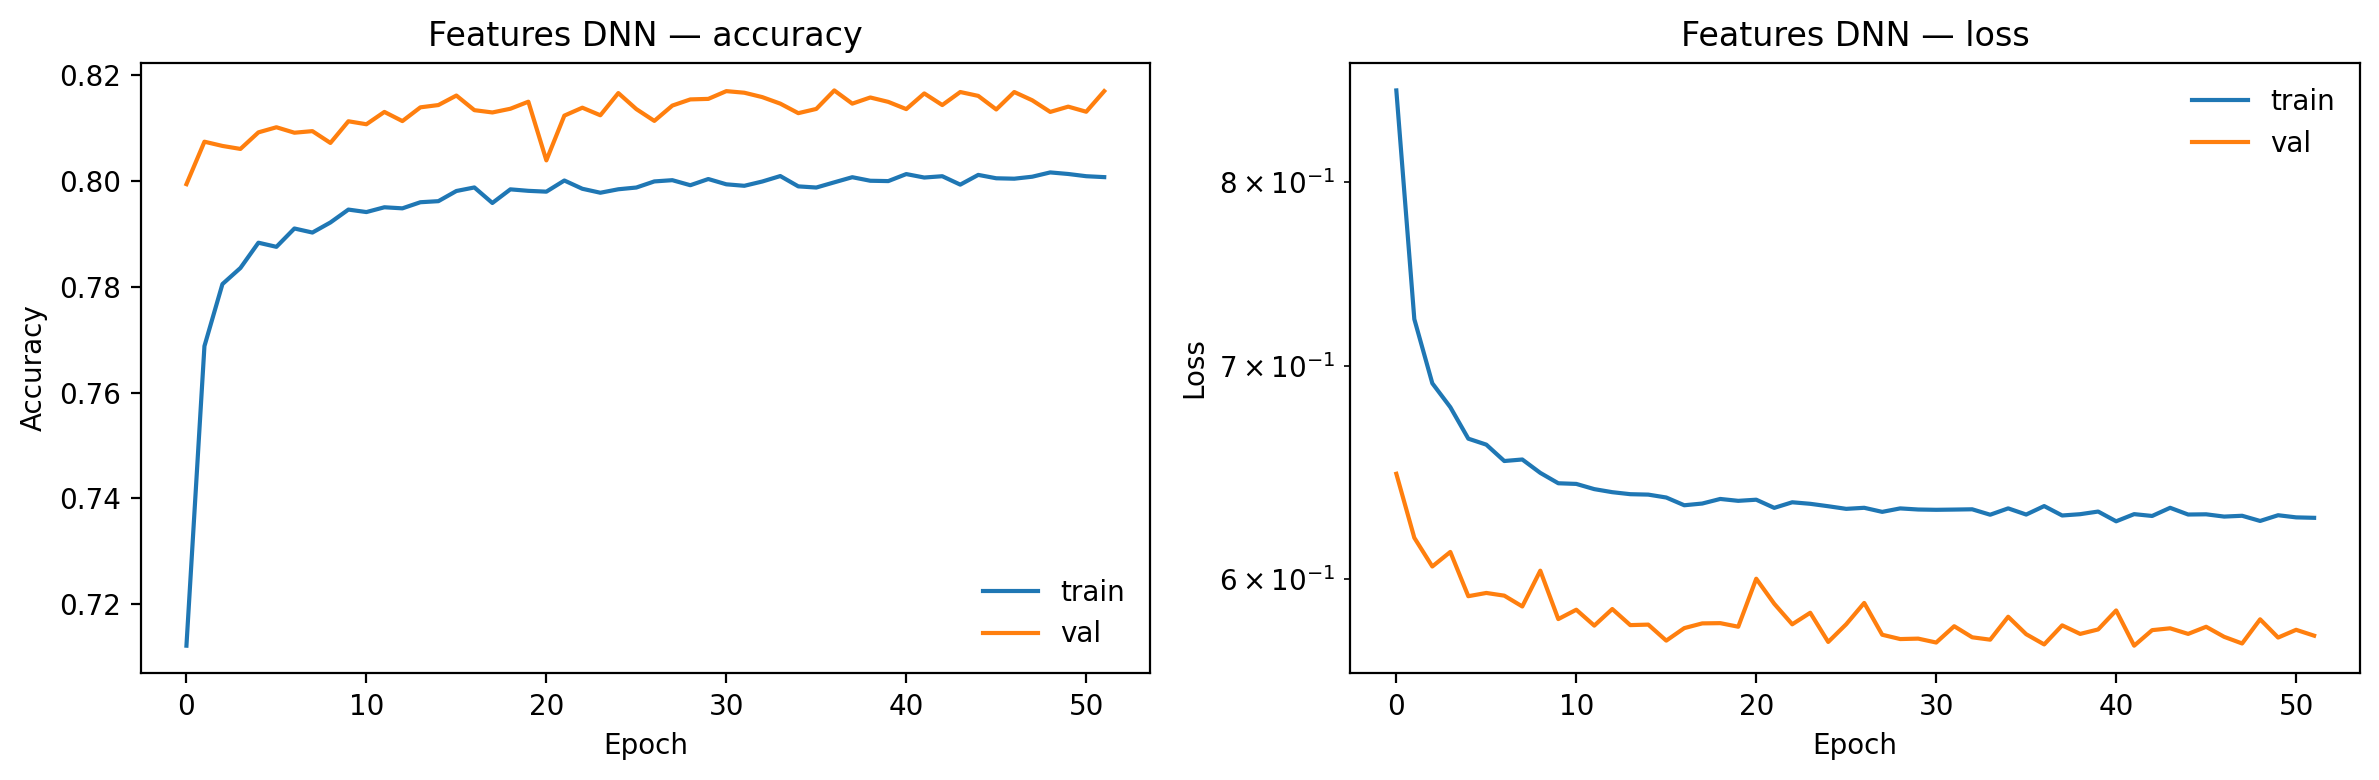

In [18]:
# Plotting training curves

model_features_dnn_dir = main_dir + '/Results/Model_features'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_features.history['accuracy'],    label='train')
axes[0].plot(history_features.history['val_accuracy'], label='val')
axes[0].set_title('Features DNN — accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_features.history['loss'],    label='train')
axes[1].plot(history_features.history['val_loss'], label='val')
axes[1].set_title('Features DNN — loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.savefig(model_features_dnn_dir + '/Plots/features_dnn_curves.pdf',
            bbox_inches='tight')
plt.show()

Training accuracy appears lower than validation accuracy due to dropout being active only during training, a known behaviour documented in Srivastava et al. (2014)

Citation:

- Srivastava et al. (2014) — "Dropout: A Simple Way to Prevent Neural Networks from Overfitting", Journal of Machine Learning Research 15, 1929–1958

In [19]:
#Loading model_v1 and datasets

val_images_p3 = np.load(main_dir + "/datasets/validation_images.npy")
val_labels_p3 = np.load(main_dir + "/datasets/validation_labels.npy")

data_images_p3 = np.load(main_dir +"/datasets/train_images.npy")
data_labels_p3 = np.load(main_dir +"/datasets/train_labels.npy")



In [20]:
val_images_p3 = val_images_p3[...,np.newaxis]
data_images_p3 = data_images_p3[...,np.newaxis]

#shuffling data

val_images_p3, val_labels_p3 = shuffle(val_images_p3, val_labels_p3, random_state = 42)
data_images_p3, data_labels_p3 = shuffle(data_images_p3, data_labels_p3, random_state=42)


#Train and Test split

split = int(0.8*len(data_images_p3))

train_images_p3 = data_images_p3[:split]
train_labels_p3 = data_labels_p3[:split]

test_images_p3 = data_images_p3[split:]
test_labels_p3 = data_labels_p3[split:]



val_images_p3.shape, val_labels_p3.shape, train_images_p3.shape, train_labels_p3.shape

((30000, 100, 100, 1), (30000,), (64000, 100, 100, 1), (64000,))

In [21]:
#Loading model_v1

model_v1 = keras.models.load_model(main_dir + '/Results/Model_v1/jet_cnn_v1.keras')


In [22]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

def get_macro_auc(model, X, y):
    '''Computes macro-averaged AUC for any model.'''
    logits = model.predict(X, batch_size=64, verbose=0)
    probs  = tf.nn.softmax(logits).numpy()
    y_bin  = label_binarize(y, classes=list(range(5)))
    return roc_auc_score(y_bin, probs, average='macro')

# Evaluate accuracy
_, acc_img  = model_v1.evaluate(test_images_p3,  test_labels_p3, verbose=0)
_, acc_feat = model_features.evaluate(test_data, test_labels,  verbose=0)

# Evaluate AUC
auc_img  = get_macro_auc(model_v1, test_images_p3, test_labels_p3)
auc_feat = get_macro_auc(model_features, test_data,   test_labels)


In [23]:
# Print comparison table
print(f"\n{'Model':<22} {'Input':<20} {'Val Acc':>10} {'Macro AUC':>12} {'Params':>12}")
print("-" * 78)
print(f"{'Image CNN (model_v1)':<22} {'100×100 calorimeter':<20} {acc_img:>10.4f} {auc_img:>12.4f} {model_v1.count_params():>12,}")
print(f"{'Features DNN':<22} {'53 jet observables':<20} {acc_feat:>10.4f} {auc_feat:>12.4f} {model_features.count_params():>12,}")


Model                  Input                   Val Acc    Macro AUC       Params
------------------------------------------------------------------------------
Image CNN (model_v1)   100×100 calorimeter      0.7272       0.9267    4,812,805
Features DNN           53 jet observables       0.8217       0.9623      115,717


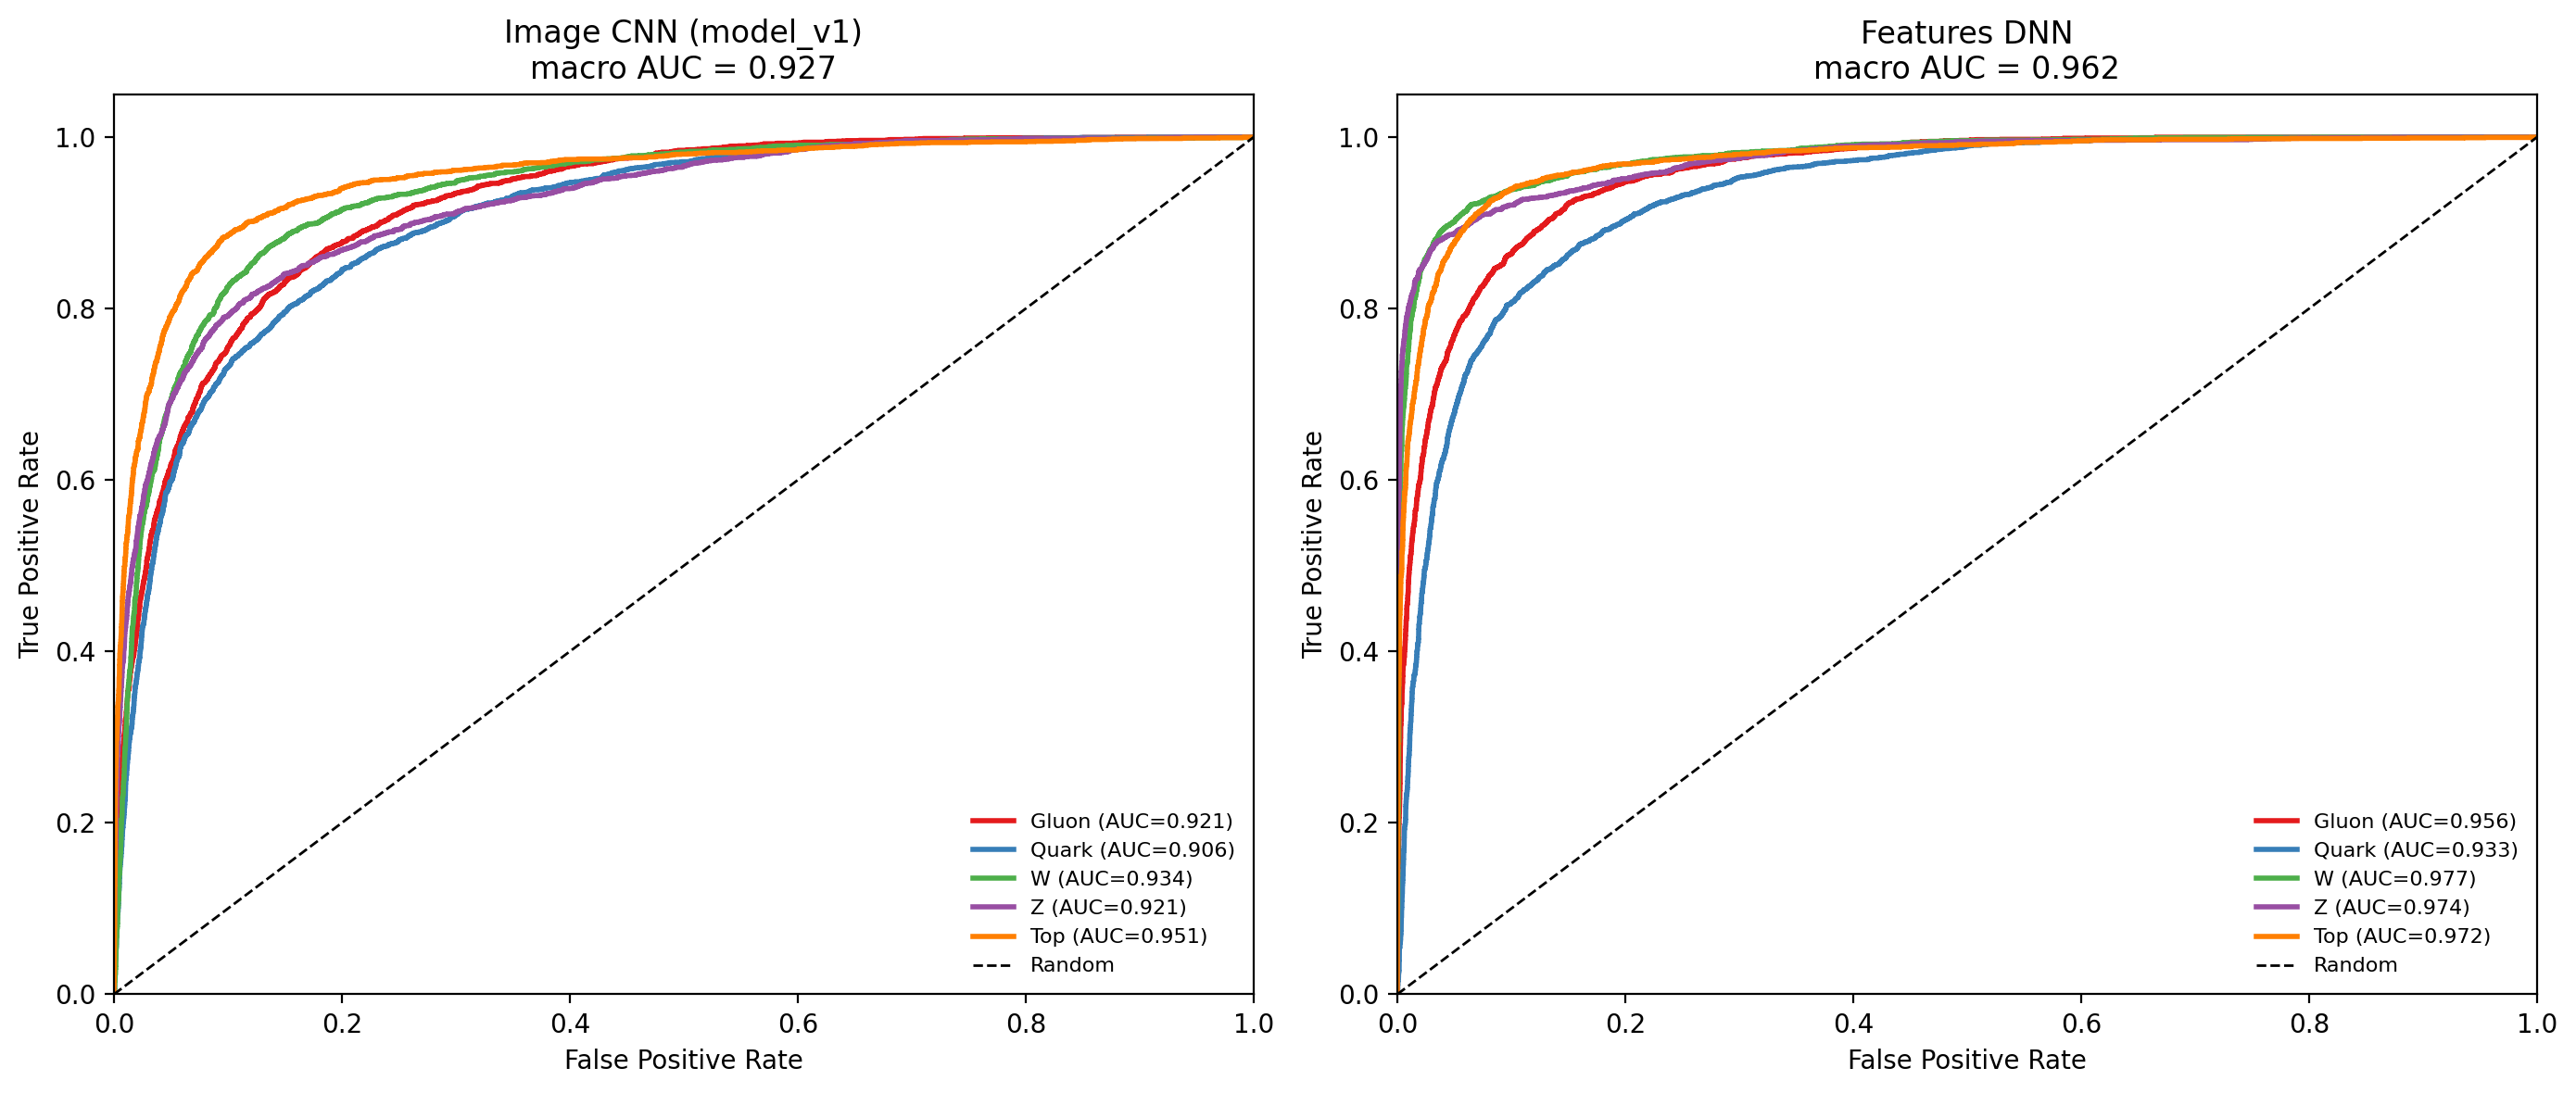

In [24]:
from sklearn.metrics import roc_curve, auc as roc_auc
import matplotlib.pyplot as plt

CLASS_NAMES = ['Gluon', 'Quark', 'W', 'Z', 'Top']
COLOURS     = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

# Get probabilities for both models
probs_img  = tf.nn.softmax(model_v1.predict(test_images_p3,  batch_size=64, verbose=0)).numpy()
probs_feat = tf.nn.softmax(model_features.predict(test_data, batch_size=64, verbose=0)).numpy()

# Binarise labels once — use same y for both since val sets are aligned
y_bin = label_binarize(test_labels, classes=list(range(5)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, probs, title in zip(
    axes,
    [probs_img, probs_feat],
    ['Image CNN (model_v1)', 'Features DNN']
):
    macro_aucs = []
    for i in range(5):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        auc_val     = roc_auc(fpr, tpr)
        macro_aucs.append(auc_val)
        ax.plot(fpr, tpr, color=COLOURS[i], linewidth=2,
                label=f"{CLASS_NAMES[i]} (AUC={auc_val:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{title}\nmacro AUC = {np.mean(macro_aucs):.3f}")
    ax.legend(loc='lower right', fontsize=8)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig(model_features_dnn_dir+ '/Plots/roc_comparison.pdf',
            bbox_inches='tight')
plt.show()

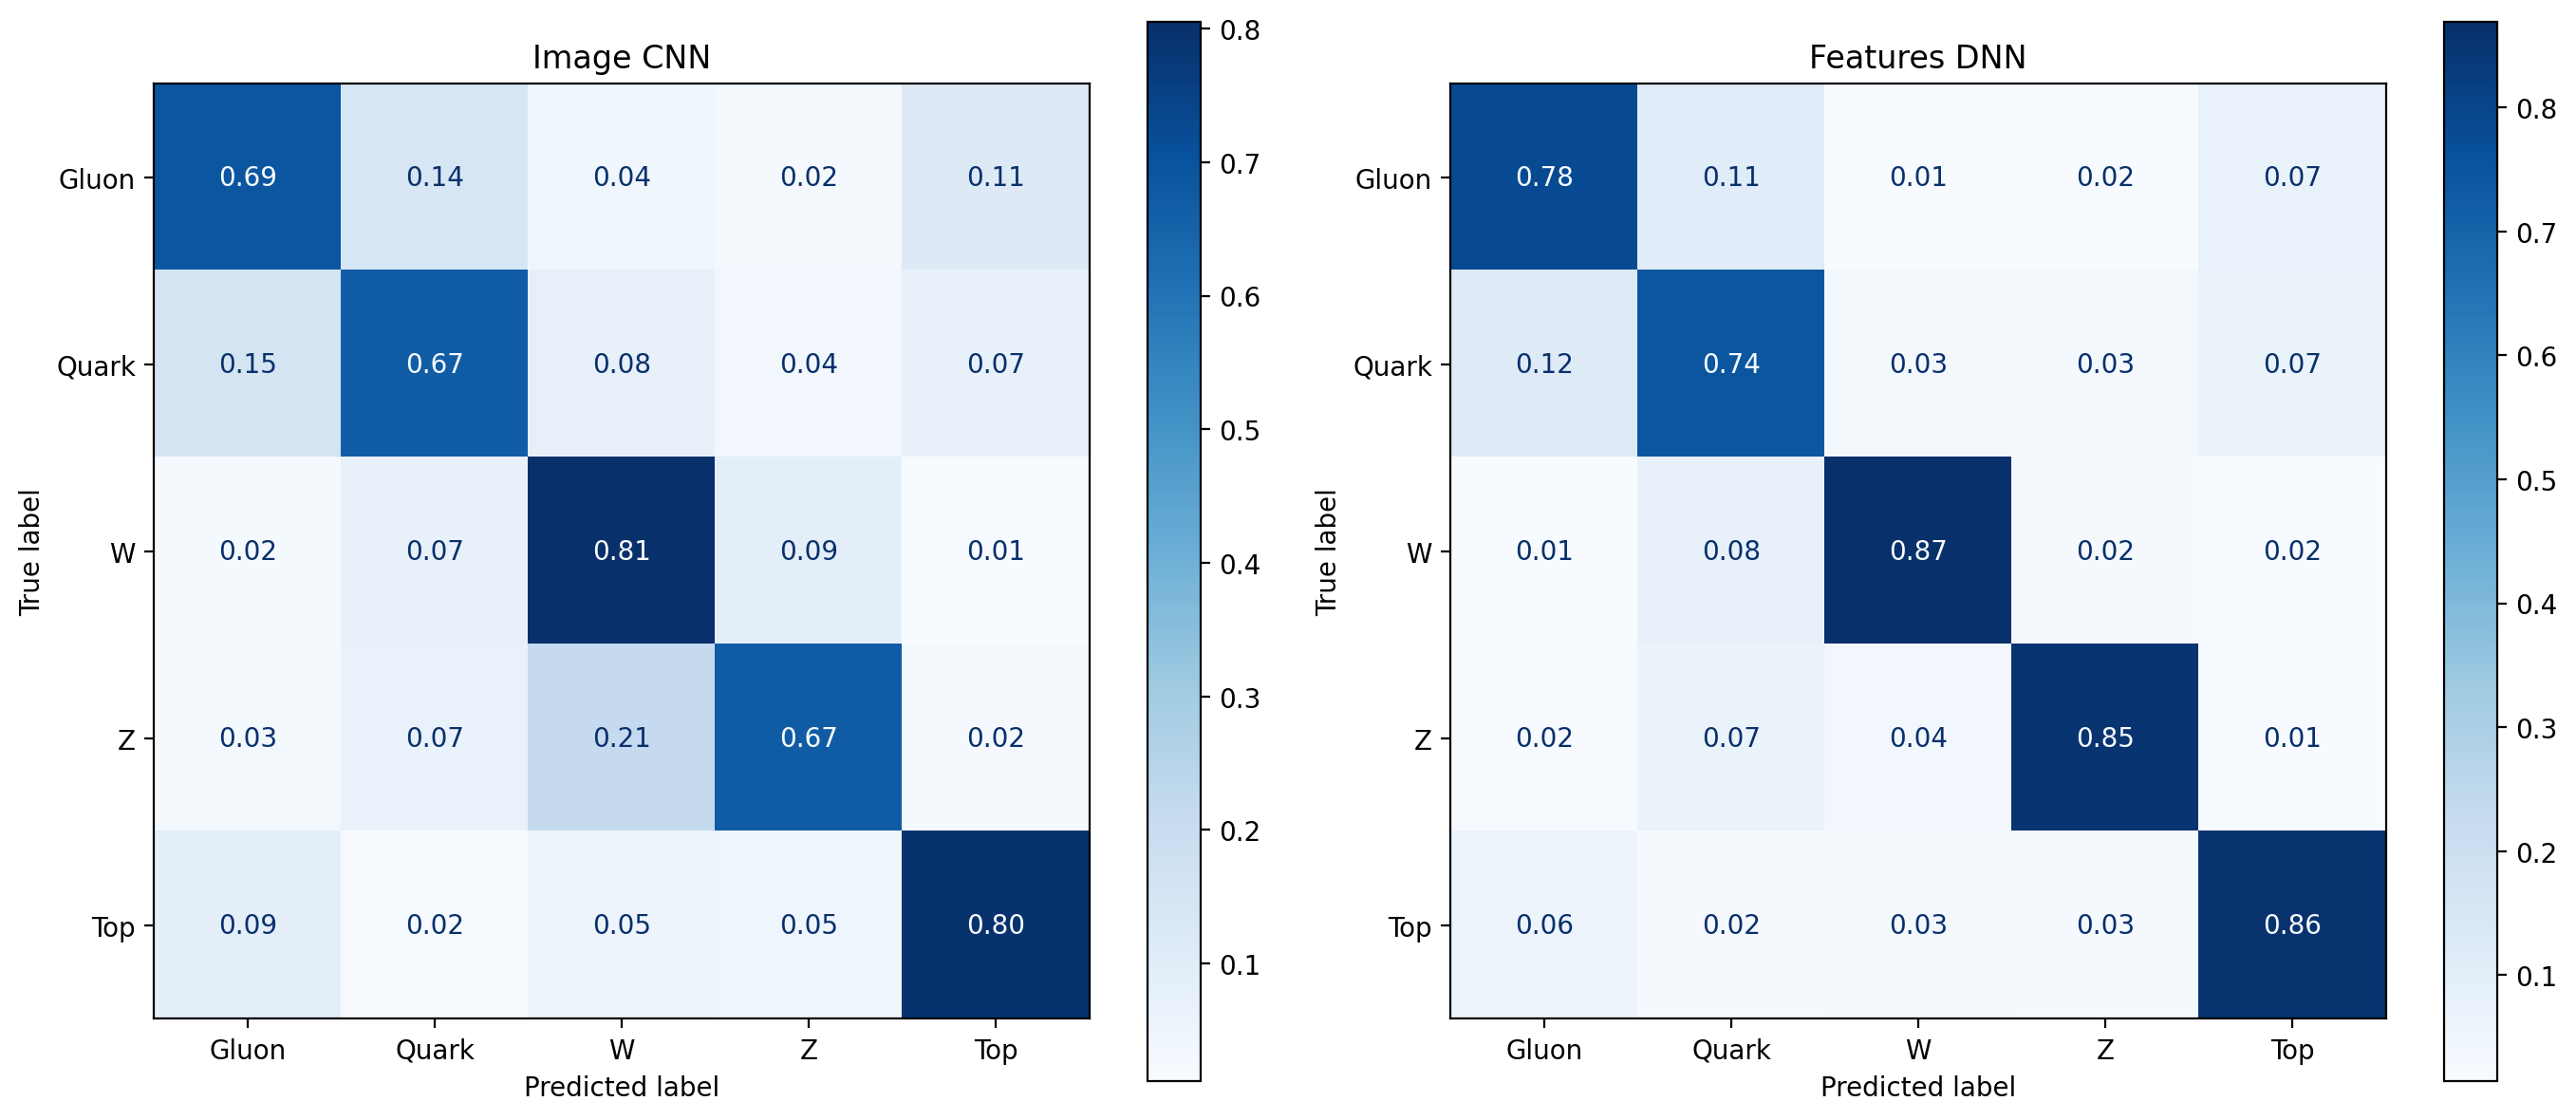

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred_img     = np.argmax(model_v1.predict(test_images_p3,  batch_size=64, verbose=0), axis=1)
pred_feat    = np.argmax(model_features.predict(test_data, batch_size=64, verbose=0), axis=1)

cm_img  = confusion_matrix(test_labels_p3, pred_img,  normalize='true')
cm_feat = confusion_matrix(test_labels, pred_feat, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cm, title in zip(
    axes,
    [cm_img, cm_feat],
    ['Image CNN', 'Features DNN']
):
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
    ax.set_title(title)

plt.tight_layout()
plt.savefig(model_features_dnn_dir + '/Plots/confusion_matrix_comparison.pdf',
            bbox_inches='tight')
plt.show()

# Results: #


- Image CNN: Z jets are misclassified as W 21% of the time — the single largest off-diagonal error in the entire matrix
- Features DNN: Z→W confusion drops to just 4% — a fivefold reduction!


The confusion matrix comparison reveals the most significant improvement of the features DNN over the image CNN: Z jet misclassification as W drops from 21% to 4% — a fivefold reduction — with the features DNN achieving a macro AUC of 0.962 compared to 0.927 for the image CNN. This quantitatively demonstrates that training a DNN on jet substructure features alone can distinguish between kinematically similar particles such as the W and Z bosons with substantially greater accuracy than a CNN trained on raw calorimeter images.



This result is consistent with the argument of de Oliveira et al. (2016), who showed that while CNNs trained on calorimeter images can learn physically meaningful substructure patterns, the raw pixel representation is insufficient to fully resolve the subtle differences between particles.
